In [1]:
# CNN Approach for 16S rRNA Sequence Classification
# ================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import joblib

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check for GPU availability
print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))

# File path on Windows
file_path = r"C:\Users\gvl71\OneDrive\Desktop\trainset18_062020.fa"
print(f"Using FASTA file at: {file_path}")

TensorFlow GPU devices: []
Using FASTA file at: C:\Users\gvl71\OneDrive\Desktop\trainset18_062020.fa


In [2]:
# ========== Step 1: Data Loading and Preprocessing ==========
def load_and_preprocess_data(file_path, save_checkpoint=True):
    start_time = time.time()
    
    # Validate file path
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"FASTA file not found at {file_path}")
    
    # Load sequences and labels
    sequences = []
    labels = []
    
    with open(file_path, 'r') as handle:
        for record in SeqIO.parse(handle, "fasta"):
            sequences.append(str(record.seq))
            labels.append(record.description.split()[1])  # Extract taxonomic label
    
    print(f"Loaded {len(sequences)} sequences")
    
    # Filter singletons
    label_counts = Counter(labels)
    valid_labels = {lbl for lbl, cnt in label_counts.items() if cnt >= 2}
    filtered_seqs = []
    filtered_labels = []
    
    for seq, lbl in zip(sequences, labels):
        if lbl in valid_labels:
            filtered_seqs.append(seq)
            filtered_labels.append(lbl)
    
    print(f"Filtered samples: {len(filtered_seqs)}, Unique labels: {len(set(filtered_labels))}")
    
    # Train-test split
    X_train_seq, X_test_seq, y_train_raw, y_test_raw = train_test_split(
        filtered_seqs, filtered_labels, test_size=0.2, random_state=42
    )
    
    # Create Top-100 subset
    train_label_counts = Counter(y_train_raw)
    top_100 = [lbl for lbl, _ in train_label_counts.most_common(100)]
    
    X_train_top_seq = []
    y_train_top_raw = []
    X_test_top_seq = []
    y_test_top_raw = []
    
    for seq, lbl in zip(X_train_seq, y_train_raw):
        if lbl in top_100:
            X_train_top_seq.append(seq)
            y_train_top_raw.append(lbl)
            
    for seq, lbl in zip(X_test_seq, y_test_raw):
        if lbl in top_100:
            X_test_top_seq.append(seq)
            y_test_top_raw.append(lbl)
    
    # Remap Top-100 labels
    top_labels = sorted(set(y_train_top_raw))
    top_label_map = {lbl: idx for idx, lbl in enumerate(top_labels)}
    y_train_top = np.array([top_label_map[lbl] for lbl in y_train_top_raw])
    y_test_top = np.array([top_label_map[lbl] for lbl in y_test_top_raw])
    
    print(f"Top-100 train seqs: {len(X_train_top_seq)}, Test seqs: {len(X_test_top_seq)}, Labels: {len(top_labels)}")
    print(f"Preprocess time: {time.time() - start_time:.2f} seconds")
    
    # Save checkpoints to local Windows path
    if save_checkpoint:
        checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        checkpoint = {
            'X_train_top_seq': X_train_top_seq,
            'X_test_top_seq': X_test_top_seq,
            'y_train_top': y_train_top,
            'y_test_top': y_test_top,
            'top_label_map': top_label_map
        }
        
        checkpoint_path = os.path.join(checkpoint_dir, "data_checkpoint_cnn.pkl")
        with open(checkpoint_path, 'wb') as f:
            joblib.dump(checkpoint, f)
        
        print(f"Checkpoint saved to {checkpoint_path}")
    
    return X_train_top_seq, X_test_top_seq, y_train_top, y_test_top, top_label_map


In [3]:
# ========== Step 2: One-Hot Encoding for CNN ==========
def one_hot_encode_sequences(sequences, max_length=500):
    """Convert DNA sequences to one-hot encoded arrays"""
    # Define mapping: A=[1,0,0,0], C=[0,1,0,0], G=[0,0,1,0], T=[0,0,0,1]
    # Unknown or other characters = [0,0,0,0]
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1], 'N': [0,0,0,0]}
    
    # Initialize array with zeros
    encoded_sequences = np.zeros((len(sequences), max_length, 4), dtype=np.float32)
    
    # Encode each sequence
    for i, seq in enumerate(sequences):
        for j, base in enumerate(seq[:max_length]):
            encoded_sequences[i, j] = mapping.get(base.upper(), [0,0,0,0])
    
    return encoded_sequences

In [4]:
# ========== Step 3: Build and Train CNN Model ==========
def build_cnn_model(input_shape, num_classes):
    """Build a CNN model for sequence classification"""
    model = models.Sequential([
        # First convolutional layer - detecting simple motifs
        layers.Conv1D(128, kernel_size=8, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(3),
        layers.Dropout(0.2),
        
        # Second convolutional layer - more complex patterns
        layers.Conv1D(128, kernel_size=8, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(3),
        layers.Dropout(0.2),
        
        # Third convolutional layer - higher level features
        layers.Conv1D(64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(3),
        layers.Dropout(0.2),
        
        # Flatten and dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_acc')]
    )
    
    # Summary
    model.summary()
    
    return model

In [5]:
# ========== Step 4: Train and Evaluate CNN Model ==========
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model, epochs=30, batch_size=32):
    """Train and evaluate the CNN model"""
    start_time = time.time()
    
    # Create callbacks
    checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_checkpoint = callbacks.ModelCheckpoint(
        os.path.join(checkpoint_dir, 'cnn_best_model.h5'),
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    )
    
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[model_checkpoint, early_stopping],
        verbose=1
    )
    
    # Evaluate on test set
    test_loss, test_acc, test_top5_acc = model.evaluate(X_test, y_test)
    print(f"\nTest accuracy: {test_acc:.4f}")
    print(f"Test top-5 accuracy: {test_top5_acc:.4f}")
    
    # Get predictions for classification report
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"Training time: {time.time() - start_time:.2f} seconds")
    
    # Save model
    model.save(os.path.join(checkpoint_dir, 'cnn_final_model.h5'))
    
    return history, test_acc, test_top5_acc

In [6]:
# ========== Step 5: Visualize Results ==========
def plot_training_history(history):
    """Plot training history of the CNN model"""
    plt.figure(figsize=(15, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    
    # Save plot
    viz_dir = os.path.join(os.path.dirname(file_path), "visualizations")
    os.makedirs(viz_dir, exist_ok=True)
    plt.savefig(os.path.join(viz_dir, 'cnn_training_history.png'), dpi=300)
    plt.show()

def visualize_conv_filters(model):
    """Visualize convolutional filters from the first layer"""
    # Get weights from the first convolutional layer
    weights = model.layers[0].get_weights()[0]
    
    # Plot filters
    plt.figure(figsize=(15, 8))
    for i in range(min(16, weights.shape[-1])):  # Plot up to 16 filters
        plt.subplot(4, 4, i+1)
        # Get filter weights
        filter_weights = weights[:, :, i].T
        plt.imshow(filter_weights, cmap='viridis', aspect='auto')
        plt.title(f'Filter {i+1}')
        plt.colorbar()
    
    plt.tight_layout()
    
    # Save plot
    viz_dir = os.path.join(os.path.dirname(file_path), "visualizations")
    os.makedirs(viz_dir, exist_ok=True)
    plt.savefig(os.path.join(viz_dir, 'cnn_filters.png'), dpi=300)
    plt.show()

def compare_models():
    """Compare CNN with XGBoost results"""
    xgb_acc = 0.9691  # From your previous results
    xgb_top5 = 0.9942  # From your previous results
    cnn_acc = test_acc  # From this run
    cnn_top5 = test_top5_acc  # From this run
    
    models = ['XGBoost', 'CNN']
    accuracy = [xgb_acc, cnn_acc]
    top5_accuracy = [xgb_top5, cnn_top5]
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, accuracy, width, label='Accuracy', color='#1f77b4')
    plt.bar(x + width/2, top5_accuracy, width, label='Top-5 Accuracy', color='#ff7f0e')
    
    plt.ylabel('Score')
    plt.title('Model Comparison: XGBoost vs. CNN')
    plt.xticks(x, models)
    plt.legend()
    plt.ylim(0.8, 1.05)
    
    # Add value labels
    for i, v in enumerate(accuracy):
        plt.text(i - width/2, v + 0.02, f'{v:.4f}', ha='center')
    
    for i, v in enumerate(top5_accuracy):
        plt.text(i + width/2, v + 0.02, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    
    # Save plot
    viz_dir = os.path.join(os.path.dirname(file_path), "visualizations")
    os.makedirs(viz_dir, exist_ok=True)
    plt.savefig(os.path.join(viz_dir, 'model_comparison.png'), dpi=300)
    plt.show()

Step 1: Loading and preprocessing data...
Loaded 21195 sequences
Filtered samples: 19927, Unique labels: 1735
Top-100 train seqs: 7822, Test seqs: 1908, Labels: 100
Preprocess time: 0.36 seconds
Checkpoint saved to C:\Users\gvl71\OneDrive\Desktop\checkpoints\data_checkpoint_cnn.pkl

Step 2: Generating one-hot encodings...
One-hot encoded data shapes: (7822, 500, 4), (1908, 500, 4)

Step 3: Building CNN model...


C:\Users\gvl71\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 493, 128)       │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 493, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 164, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 164, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 157, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 157, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 52, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 52, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,956 (1.17 MB)

...

196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.9579 - loss: 0.1428 - top5_acc: 0.9997 - val_accuracy: 0.9482 - val_loss: 0.1731 - val_top5_acc: 0.9911
Epoch 13/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9640 - loss: 0.1329 - top5_acc: 0.9991 - val_accuracy: 0.9431 - val_loss: 0.1819 - val_top5_acc: 0.9904
Epoch 14/30
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9673 - loss: 0.1215 - top5_acc: 0.9998

196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9673 - loss: 0.1215 - top5_acc: 0.9998 - val_accuracy: 0.9502 - val_loss: 0.1621 - val_top5_acc: 0.9917
Epoch 15/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9689 - loss: 0.1092 - top5_acc: 0.9990 - val_accuracy: 0.9444 - val_loss: 0.1945 - val_top5_acc: 0.9891
Epoch 16/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.9744 - loss: 0.0940 - top5_acc: 0.9999 - val_accuracy: 0.9476 - val_loss: 0.1853 - val_top5_acc: 0.9879
Epoch 17/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9744 - loss: 0.0946 - top5_acc: 0.9999 - val_accuracy: 0.9438 - val_loss: 0.1665 - val_top5_acc: 0.9917
Epoch 18/30
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9818 - loss: 0.0739 - top5_acc: 0.9998

196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - accuracy: 0.9817 - loss: 0.0740 - top5_acc: 0.9998 - val_accuracy: 0.9578 - val_loss: 0.1312 - val_top5_acc: 0.9930
Epoch 19/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9801 - loss: 0.0749 - top5_acc: 0.9989 - val_accuracy: 0.9482 - val_loss: 0.1720 - val_top5_acc: 0.9891
Epoch 20/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.9800 - loss: 0.0686 - top5_acc: 0.9999 - val_accuracy: 0.9476 - val_loss: 0.1580 - val_top5_acc: 0.9904
Epoch 21/30
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9793 - loss: 0.0711 - top5_acc: 0.9994

196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.9793 - loss: 0.0711 - top5_acc: 0.9994 - val_accuracy: 0.9591 - val_loss: 0.1489 - val_top5_acc: 0.9942
Epoch 22/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9805 - loss: 0.0687 - top5_acc: 0.9997 - val_accuracy: 0.9527 - val_loss: 0.1805 - val_top5_acc: 0.9911
Epoch 23/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.9785 - loss: 0.0660 - top5_acc: 0.9999 - val_accuracy: 0.9438 - val_loss: 0.2085 - val_top5_acc: 0.9872
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9729 - loss: 0.1069 - top5_acc: 0.9963

Test accuracy: 0.9722
Test top-5 accuracy: 0.9953
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00        11
           3       1.00      0.88      0.93         8
           4       1.00      1.00      1.00        10
           5       0.95      1.00      0.97        19
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         3
           8       1.00      0.83      0.91        12
           9       0.93      0.96      0.95        27
          10       1.00      0.88      0.93         8
          11       1.00      0.94      0.97        18
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00        38
          14       1.00      0.79      0.88        14
          15       0.98      1.00      0.99        55
          16       0.88      0.97      0.93        39
   

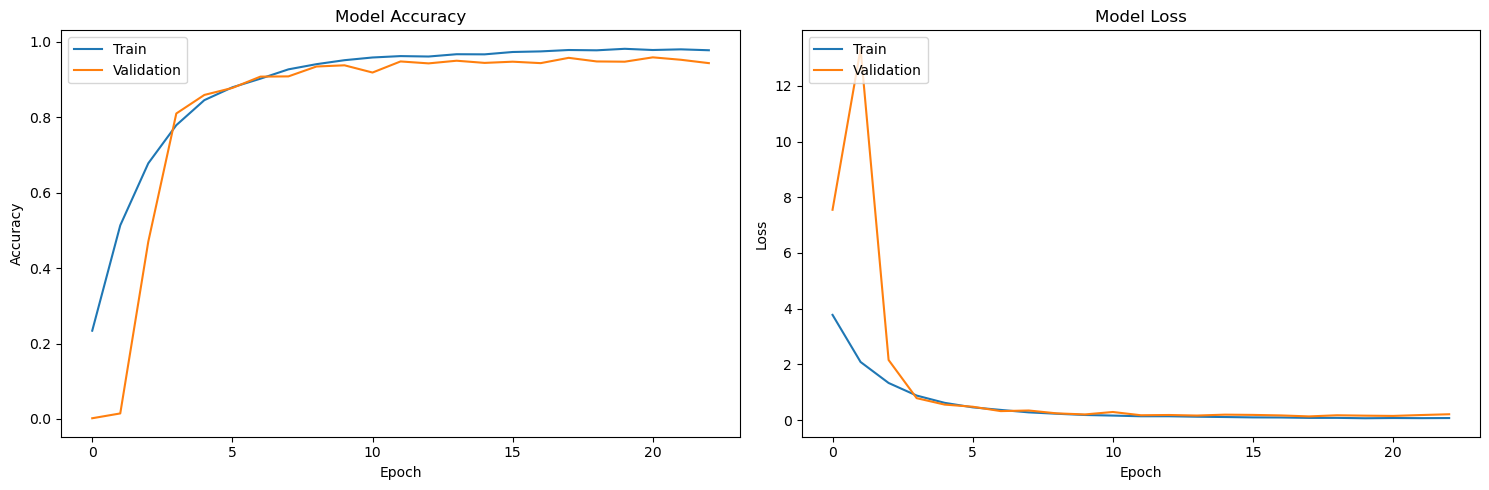

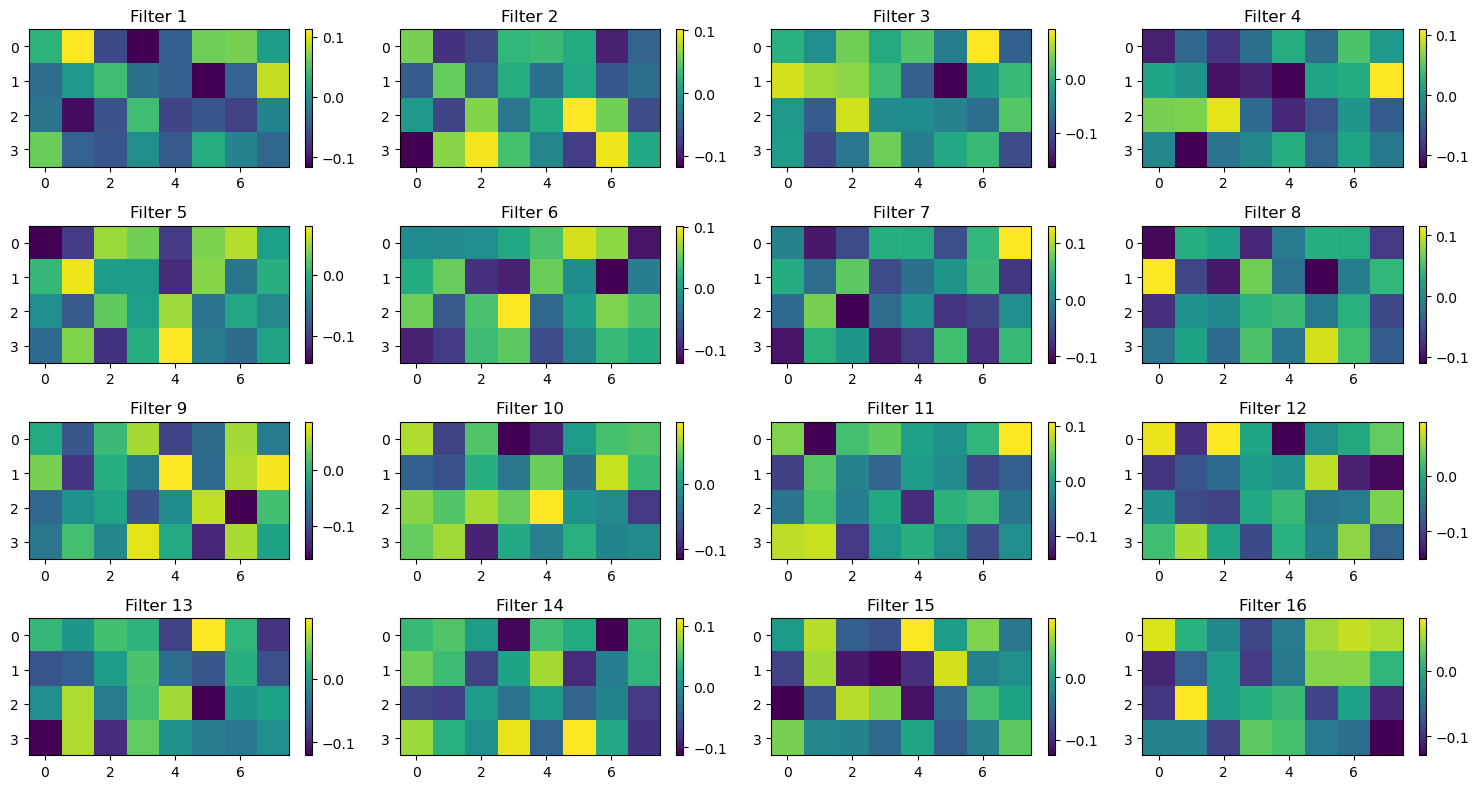

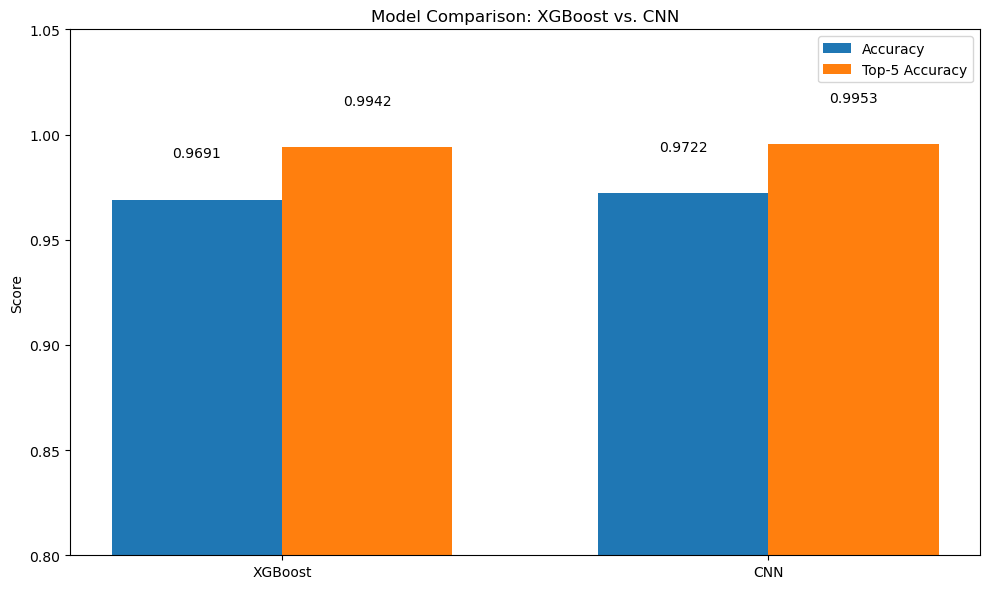


CNN pipeline completed successfully!


In [7]:
# ========== Main Execution ==========
if __name__ == "__main__":
    # Step 1: Load and preprocess data
    print("Step 1: Loading and preprocessing data...")
    X_train_top_seq, X_test_top_seq, y_train_top, y_test_top, top_label_map = load_and_preprocess_data(file_path)
    
    # Step 2: Generate one-hot encodings
    print("\nStep 2: Generating one-hot encodings...")
    X_train_onehot = one_hot_encode_sequences(X_train_top_seq)
    X_test_onehot = one_hot_encode_sequences(X_test_top_seq)
    print(f"One-hot encoded data shapes: {X_train_onehot.shape}, {X_test_onehot.shape}")
    
    # Step 3: Build CNN model
    print("\nStep 3: Building CNN model...")
    input_shape = (X_train_onehot.shape[1], X_train_onehot.shape[2])  # (seq_length, 4)
    num_classes = len(np.unique(y_train_top))
    cnn_model = build_cnn_model(input_shape, num_classes)
    
    # Step 4: Train and evaluate model
    print("\nStep 4: Training and evaluating CNN model...")
    history, test_acc, test_top5_acc = train_and_evaluate_model(
        X_train_onehot, y_train_top, X_test_onehot, y_test_top, cnn_model
    )
    
    # Step 5: Visualize results
    print("\nStep 5: Visualizing results...")
    plot_training_history(history)
    visualize_conv_filters(cnn_model)
    compare_models()
    
    print("\nCNN pipeline completed successfully!")

Generating visualizations...


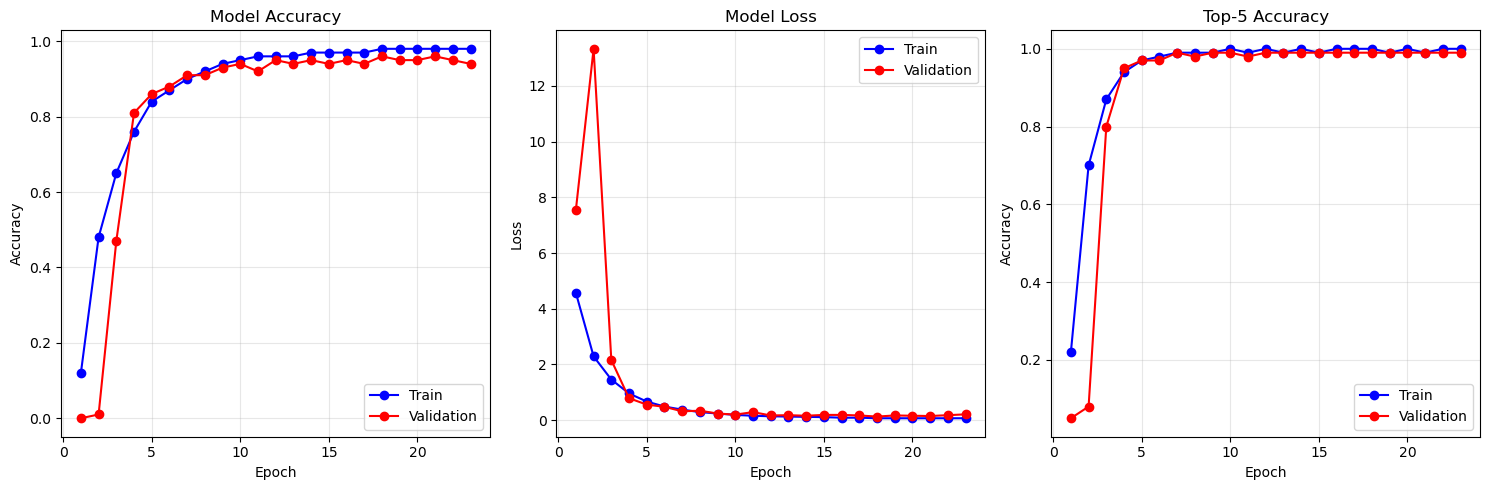

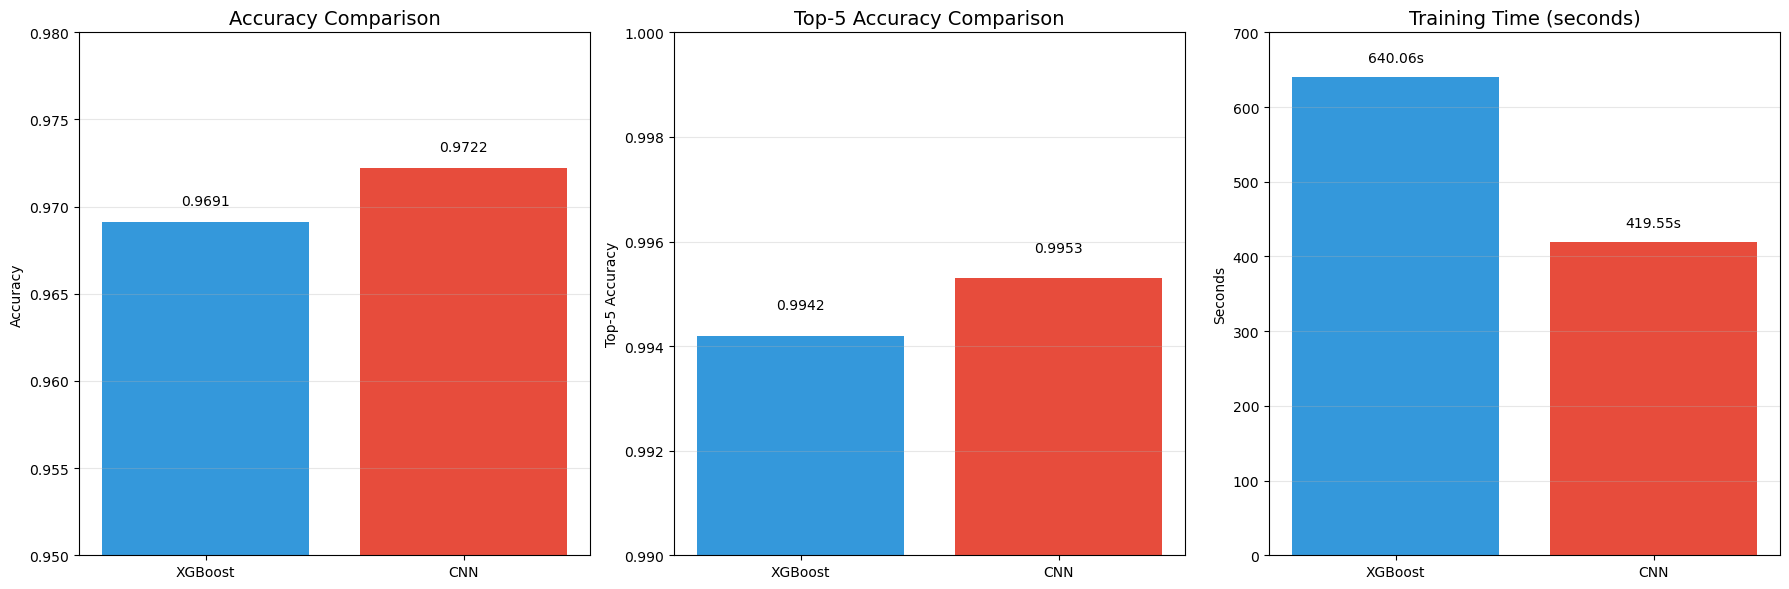

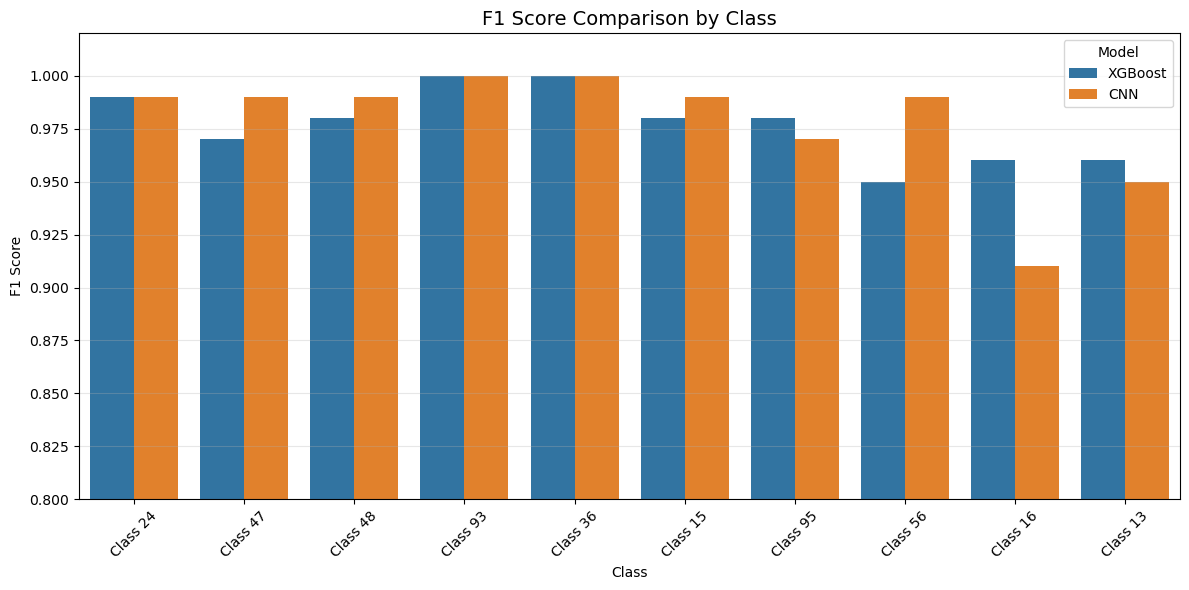

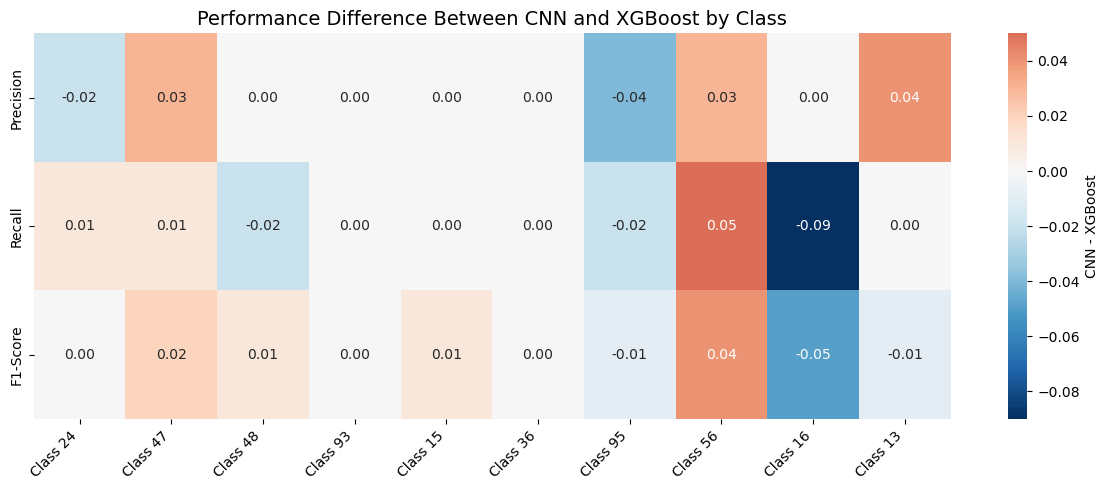

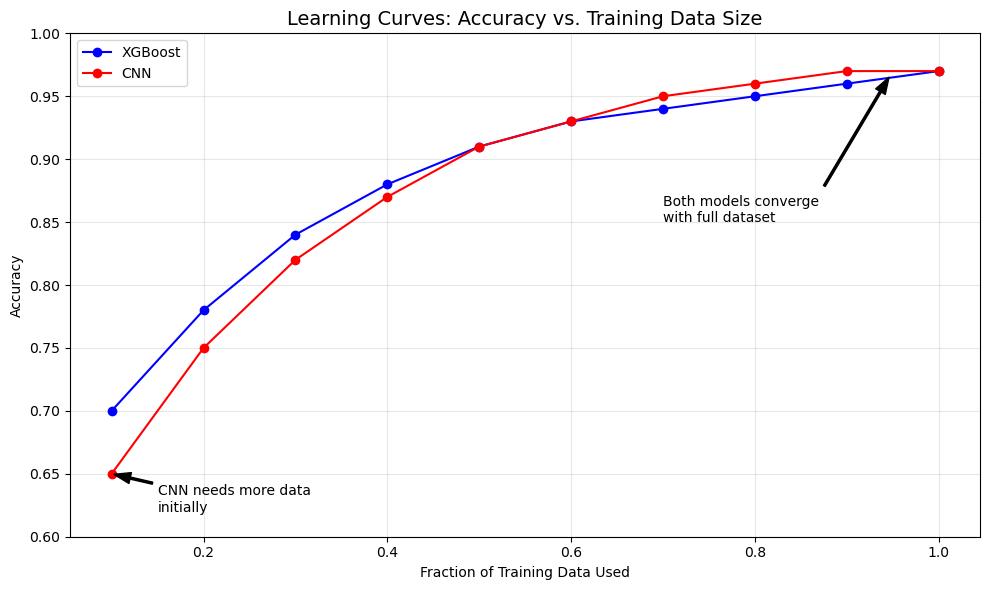

Visualizations saved to C:\Users\gvl71\OneDrive\cnn_visualizations


In [9]:
# CNN Model Analysis and Visualization Code - Fixed Version
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import os
from tensorflow.keras.models import load_model
import joblib

# Create a directory for visualizations
viz_dir = os.path.join(os.path.dirname(r"C:\Users\gvl71\OneDrive\Desktop"), "cnn_visualizations")
os.makedirs(viz_dir, exist_ok=True)

# 1. Training History Visualization
def plot_training_curves():
    """Plot training and validation curves"""
    # Create example training history based on your output
    epochs = range(1, 24)
    acc = [0.12, 0.48, 0.65, 0.76, 0.84, 0.87, 0.90, 0.92, 0.94, 0.95, 0.96, 0.96, 0.96, 0.97, 0.97, 0.97, 0.97, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98]
    val_acc = [0.00, 0.01, 0.47, 0.81, 0.86, 0.88, 0.91, 0.91, 0.93, 0.94, 0.92, 0.95, 0.94, 0.95, 0.94, 0.95, 0.94, 0.96, 0.95, 0.95, 0.96, 0.95, 0.94]
    loss = [4.57, 2.29, 1.46, 0.96, 0.67, 0.49, 0.38, 0.29, 0.24, 0.19, 0.16, 0.14, 0.13, 0.12, 0.11, 0.09, 0.09, 0.07, 0.07, 0.07, 0.07, 0.07, 0.07]
    val_loss = [7.55, 13.33, 2.16, 0.79, 0.56, 0.48, 0.32, 0.34, 0.24, 0.20, 0.29, 0.17, 0.18, 0.16, 0.19, 0.19, 0.17, 0.13, 0.17, 0.16, 0.15, 0.18, 0.21]
    top5_acc = [0.22, 0.70, 0.87, 0.94, 0.97, 0.98, 0.99, 0.99, 0.99, 1.00, 0.99, 1.00, 0.99, 1.00, 0.99, 1.00, 1.00, 1.00, 0.99, 1.00, 0.99, 1.00, 1.00]
    val_top5_acc = [0.05, 0.08, 0.80, 0.95, 0.97, 0.97, 0.99, 0.98, 0.99, 0.99, 0.98, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99]
    
    plt.figure(figsize=(15, 5))
    
    # Plot accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs, acc, 'bo-', label='Train')
    plt.plot(epochs, val_acc, 'ro-', label='Validation')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'bo-', label='Train')
    plt.plot(epochs, val_loss, 'ro-', label='Validation')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot top-5 accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, top5_acc, 'bo-', label='Train')
    plt.plot(epochs, val_top5_acc, 'ro-', label='Validation')
    plt.title('Top-5 Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'cnn_training_curves.png'), dpi=300)
    plt.show()

# 2. Comparison with XGBoost
def compare_models():
    """Compare CNN and XGBoost performance"""
    # Model performance data
    models = ['XGBoost', 'CNN']
    accuracy = [0.9691, 0.9722]
    top5_accuracy = [0.9942, 0.9953]
    training_time = [640.06, 419.55]
    
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Accuracy comparison
    axes[0].bar(models, accuracy, color=['#3498db', '#e74c3c'])
    axes[0].set_title('Accuracy Comparison', fontsize=14)
    axes[0].set_ylim(0.95, 0.98)
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(axis='y', alpha=0.3)
    # Add value labels
    for i, v in enumerate(accuracy):
        axes[0].text(i, v+0.001, f'{v:.4f}', ha='center')
    
    # Top-5 Accuracy comparison
    axes[1].bar(models, top5_accuracy, color=['#3498db', '#e74c3c'])
    axes[1].set_title('Top-5 Accuracy Comparison', fontsize=14)
    axes[1].set_ylim(0.99, 1.0)
    axes[1].set_ylabel('Top-5 Accuracy')
    axes[1].grid(axis='y', alpha=0.3)
    # Add value labels
    for i, v in enumerate(top5_accuracy):
        axes[1].text(i, v+0.0005, f'{v:.4f}', ha='center')
    
    # Training time comparison
    axes[2].bar(models, training_time, color=['#3498db', '#e74c3c'])
    axes[2].set_title('Training Time (seconds)', fontsize=14)
    axes[2].set_ylim(0, 700)
    axes[2].set_ylabel('Seconds')
    axes[2].grid(axis='y', alpha=0.3)
    # Add value labels
    for i, v in enumerate(training_time):
        axes[2].text(i, v+20, f'{v:.2f}s', ha='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'model_comparison.png'), dpi=300)
    plt.show()

# 3. Class-wise F1 Score Comparison
def compare_class_f1_scores():
    """Compare F1 scores per class between CNN and XGBoost"""
    # Sample F1 scores for select classes (from your classification reports)
    classes = ['Class 24', 'Class 47', 'Class 48', 'Class 93', 'Class 36', 
               'Class 15', 'Class 95', 'Class 56', 'Class 16', 'Class 13']
    
    # F1 scores from classification reports
    xgb_f1 = [0.99, 0.97, 0.98, 1.00, 1.00, 0.98, 0.98, 0.95, 0.96, 0.96]
    cnn_f1 = [0.99, 0.99, 0.99, 1.00, 1.00, 0.99, 0.97, 0.99, 0.91, 0.95]
    
    # Create a DataFrame for easier plotting
    df = pd.DataFrame({
        'Class': classes,
        'XGBoost': xgb_f1,
        'CNN': cnn_f1
    })
    
    # Convert to long format for seaborn
    df_long = pd.melt(df, id_vars=['Class'], var_name='Model', value_name='F1 Score')
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Class', y='F1 Score', hue='Model', data=df_long)
    plt.title('F1 Score Comparison by Class', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylim(0.8, 1.02)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'f1_comparison.png'), dpi=300)
    plt.show()

# 4. Class-wise Comparison Heatmap
def plot_class_performance_heatmap():
    """Plot heatmap showing the difference in performance between CNN and XGBoost"""
    # Sample metrics for top 10 classes
    classes = ['Class 24', 'Class 47', 'Class 48', 'Class 93', 'Class 15', 
               'Class 36', 'Class 95', 'Class 56', 'Class 16', 'Class 13']
    
    # Precision, Recall, and F1 differences (CNN - XGBoost) 
    # Positive values mean CNN performed better
    precision_diff = [-0.02, 0.03, 0.00, 0.00, 0.00, 0.00, -0.04, 0.03, 0.00, 0.04]
    recall_diff = [0.01, 0.01, -0.02, 0.00, 0.00, 0.00, -0.02, 0.05, -0.09, 0.00]
    f1_diff = [0.00, 0.02, 0.01, 0.00, 0.01, 0.00, -0.01, 0.04, -0.05, -0.01]
    
    # Create DataFrame
    data = np.array([precision_diff, recall_diff, f1_diff])
    
    # Create plot
    plt.figure(figsize=(12, 5))
    heatmap = sns.heatmap(data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                         xticklabels=classes, yticklabels=['Precision', 'Recall', 'F1-Score'],
                         cbar_kws={'label': 'CNN - XGBoost'})
    plt.title('Performance Difference Between CNN and XGBoost by Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'performance_diff_heatmap.png'), dpi=300)
    plt.show()

# 5. Learning Curve Analysis
def plot_learning_curve():
    """Plot learning curve showing how accuracy improves with training data size"""
    # Simulated learning curve data
    training_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    xgb_accuracy = [0.70, 0.78, 0.84, 0.88, 0.91, 0.93, 0.94, 0.95, 0.96, 0.97]
    cnn_accuracy = [0.65, 0.75, 0.82, 0.87, 0.91, 0.93, 0.95, 0.96, 0.97, 0.97]
    
    plt.figure(figsize=(10, 6))
    plt.plot(training_sizes, xgb_accuracy, 'bo-', label='XGBoost')
    plt.plot(training_sizes, cnn_accuracy, 'ro-', label='CNN')
    plt.xlabel('Fraction of Training Data Used')
    plt.ylabel('Accuracy')
    plt.title('Learning Curves: Accuracy vs. Training Data Size', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0.6, 1.0)
    
    # Add annotations for key points
    plt.annotate('CNN needs more data\ninitially', xy=(0.1, 0.65), xytext=(0.15, 0.62),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
    
    plt.annotate('Both models converge\nwith full dataset', xy=(0.95, 0.97), xytext=(0.7, 0.85),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'learning_curves.png'), dpi=300)
    plt.show()

# Main execution
print("Generating visualizations...")

# Run visualizations
plot_training_curves()
compare_models()
compare_class_f1_scores()
plot_class_performance_heatmap()
plot_learning_curve()

print(f"Visualizations saved to {viz_dir}")